# Load your image dataset

Sample shape: torch.Size([3, 224, 224]), Label: class1


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type (var_name))                                                Input Shape               Output Shape              Param #
ViTClassifier (ViTClassifier)                                          [32, 3, 224, 224]         [32, 2]                   --
├─ViTModel (vit)                                                       --                        [32, 768]                 --
│    └─ViTEmbeddings (embeddings)                                      [32, 3, 224, 224]         [32, 197, 768]            152,064
│    │    └─ViTPatchEmbeddings (patch_embeddings)                      [32, 3, 224, 224]         [32, 196, 768]            (590,592)
│    │    └─Dropout (dropout)                                          [32, 197, 768]            [32, 197, 768]            --
│    └─ViTEncoder (encoder)                                            [32, 197, 768]            [32, 197, 768]            --
│    │    └─ModuleList (layer)                                         --                        --  

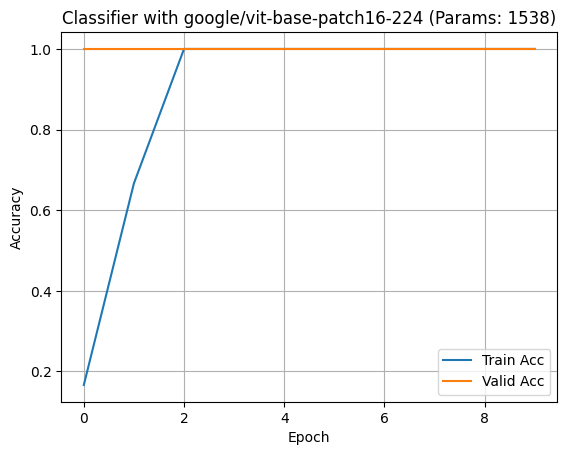

Test Accuracy: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
model_names = ["google/vit-base-patch16-224",
               "microsoft/beit-base-patch16-224",
               "facebook/vit-mae-base"]
pretrained_model = model_names[0]

# (1) Data Loading and Preprocessing
from transformers import AutoImageProcessor
processor = AutoImageProcessor.from_pretrained(pretrained_model, use_fast=True)
image_size = processor.size["height"]

import torch
from torch.utils.data import DataLoader

from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Load your dataset
# Save the image data in the following folder structure.
# ./data/my_image_dataset/
# 　├ train/
# 　│　├ class1/
# 　│　│　　├ 1.png
# 　│　│　　└ ...
# 　│　├ class2/
# 　│　│　　├ 2.png
# 　│　│ 　└ ... 
# 　├ test/
# 　│　├ class1/
# 　│　│　　├ 3.png
# 　│　│　　└ ...
# 　│　├ class2/
# 　│　│　　├ 4.png
# 　│　│ 　└ ... 
from torchvision import datasets
trainval_dataset = datasets.ImageFolder(root='./data/my_image_dataset/train', transform=transform)
test_dataset = datasets.ImageFolder(root='./data/my_image_dataset/test', transform=transform)
num_classes = len(trainval_dataset.classes)

# Split trainval into train and validation sets
train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=64)

# Print the first sample
x, y = trainval_dataset[0]
print(f"Sample shape: {x.shape}, Label: {trainval_dataset.classes[y]}")

# (2) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, optimizer, device):
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            inputs = processor(images=list(x), return_tensors="pt", do_rescale=False)
            x, y = inputs['pixel_values'].to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                inputs = processor(images=list(x), return_tensors="pt", do_rescale=False)
                x, y = inputs['pixel_values'].to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (3) Definition of the model and optimizer
from torch import nn
from transformers import AutoModel
import torchinfo

class ViTClassifier(nn.Module):
    def __init__(self, pretrained_model, num_classes, freeze_encoder=True):
        super().__init__()
        self.vit = AutoModel.from_pretrained(pretrained_model)
        if freeze_encoder:
            for param in self.vit.parameters():
                param.requires_grad = False
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]  # [CLS]
        logits = self.classifier(cls_token)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViTClassifier(pretrained_model, num_classes, freeze_encoder=True).to(device)
print(torchinfo.summary(model, input_size=(32, 3, 224, 224), row_settings=["var_names"],
                        col_names=["input_size", "output_size", "num_params"]))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# (4) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
train_accs, test_accs, best_state = train(train_loader, val_loader, model, optimizer, device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Classifier with {pretrained_model} (Params: {num_params})")
plt.legend()
plt.grid(True)
plt.show()

# (5) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        inputs = processor(images=list(x), return_tensors="pt", do_rescale=False)
        x, y = inputs['pixel_values'].to(device), y.to(device)
        out = model(x)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Load your text dataset

Vocabulary size: 30522


Casting the dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/12 [00:00<?, ? examples/s]

Number of classes: 2


Map:   0%|          | 0/12 [00:00<?, ? examples/s]

Map:   0%|          | 0/12 [00:00<?, ? examples/s]

First example from the dataset:
Sentence: [CLS] once again mr. costner has dragged out a movie for far longer than necessary. [SEP]
Label: tensor(0)
Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
TransformerEncoderClassifier                                 [32, 64]                  [32, 2]                   --
├─BertModel: 1-1                                             --                        [32, 768]                 --
│    └─BertEmbeddings: 2-1                                   --                        [32, 64, 768]             --
│    │    └─Embedding: 3-1                                   [32, 64]                  [32, 64, 768]             (23,440,896)
│    │    └─Embedding: 3-2                                   [32, 64]                  [32, 64, 768]             (1,536)
│    │    └─Embedding: 3-3                                   [1, 64]                   [1, 64, 768]              (393,216)
│    │    └─

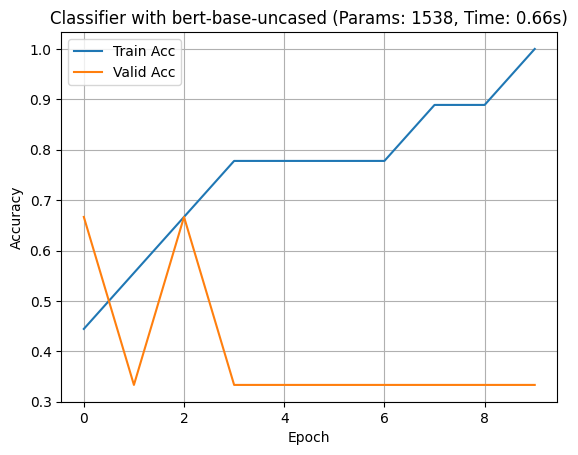

Test Accuracy: 0.833
              precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



In [ ]:
model_names = ["bert-base-uncased",
               "distilbert-base-uncased",
               "google/electra-base-discriminator"]
pretrained_model = model_names[0]

# (1) Data Loading
# Tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model)
vocab_size = tokenizer.vocab_size
print(f"Vocabulary size: {vocab_size}")

# Load your text dataset
# This code assumes that you have train.tsv and test.tsv files in the data/my_text_dataset folder, 
# which contain tab-delimited pairs of "text" and "label" for each line.
# Example of train.tsv:
#
# text	label
# Hello, world.	class1
# How are you?	class1
# I love programming.	class2
# I like machine learning.	class2
from datasets import load_dataset
from datasets import ClassLabel
dataset = load_dataset("csv", delimiter="\t",
                        data_files={"train": "./data/my_text_dataset/train.tsv",
                                    "test": "./data/my_text_dataset/test.tsv",})
class_names = sorted(set(dataset['train']['label']))
class_label = ClassLabel(names=class_names)
dataset = dataset.cast_column("label", class_label)
num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=False)
tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

# (2) DataLoader with padding
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = pad_sequence([x["input_ids"] for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_mask = pad_sequence([x["attention_mask"] for x in batch], batch_first=True, padding_value=0)
    labels = torch.tensor([x["label"] for x in batch])
    return input_ids, attn_mask, labels

tokenized_trainval = tokenized["train"].train_test_split(test_size=0.2, seed=42)
train_loader = DataLoader(tokenized_trainval["train"], batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(tokenized_trainval["test"], batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(tokenized["test"], batch_size=64, shuffle=False, collate_fn=collate_fn)

# Print the first example
print("First example from the dataset:")
print("Sentence:", tokenizer.decode(tokenized["train"][0]["input_ids"]))
print("Label:", tokenized["train"][0]["label"])

# (3) Model Definition
import torch.nn as nn
from transformers import AutoModel

# Transformer Encoder Classifier
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, pretrained_model, num_classes, freeze_encoder=True):
        super(TransformerEncoderClassifier, self).__init__()
        self.encoder = AutoModel.from_pretrained(pretrained_model)
        # Freeze pre-trained model parameters
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, x, mask):
        outputs = self.encoder(input_ids=x, attention_mask=mask) # [batch_size, seq_len, hidden_size]
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token vector, [batch_size, hidden_size]
        logits = self.classifier(cls_output)  # [batch_size, num_classes]
        return logits


# (4) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, mask, y in train_loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, mask)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in val_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device)
                out = model(x, mask)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (5) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
import torchinfo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerEncoderClassifier(pretrained_model, num_classes).to(device)

print(torchinfo.summary(
    model,
    input_data=(torch.randint(0, vocab_size, (32, 64), device=device), 
                torch.ones(32, 64, dtype=torch.int64, device=device)),
    col_names=["input_size", "output_size", "num_params"]
))

# Measure the training time
import time
start_time = time.time()
print("Starting training...")
train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
end_time = time.time()
execution_time = end_time - start_time
print(f"Training time: {execution_time:.2f} seconds")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Classifier with {pretrained_model} (Params: {num_params}, Time: {execution_time:.2f}s)")
plt.legend()
plt.grid(True)
plt.show()

# (6) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, mask, y in test_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        out = model(x, mask)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))

In [6]:
# Generate dummy csv dataset
import numpy as np
import pandas as pd
import os

# 出力ディレクトリ作成
os.makedirs("data", exist_ok=True)

# 特徴量の数と各クラスのインスタンス数
num_features = 10
num_instances_per_class = 50

# クラスごとの平均をランダムに決定
np.random.seed(42)  # 再現性のための乱数シード
mean_class_0 = np.random.uniform(-5, 5, size=num_features)
mean_class_1 = np.random.uniform(-5, 5, size=num_features)

# データの生成（各特徴量は N(μ, 1) の正規分布）
data_class_0 = np.random.normal(loc=mean_class_0, scale=1.0, size=(num_instances_per_class, num_features))
data_class_1 = np.random.normal(loc=mean_class_1, scale=1.0, size=(num_instances_per_class, num_features))

# ラベル付与
labels_0 = np.zeros((num_instances_per_class, 1))
labels_1 = np.ones((num_instances_per_class, 1))

# 結合
data_0 = np.hstack((data_class_0, labels_0))
data_1 = np.hstack((data_class_1, labels_1))
data_all = np.vstack((data_0, data_1))

# データフレームに変換
columns = [f"feature_{i}" for i in range(num_features)] + ["label"]
df = pd.DataFrame(data_all, columns=columns)

# シャッフル（任意）
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# CSVとして保存
output_path = "data/my_csv_dataset.csv"
df.to_csv(output_path, index=False)

print(f"ダミーデータを {output_path} に保存しました。")


ダミーデータを data/my_csv_dataset.csv に保存しました。


# Load your CSV dataset

In [9]:
# (1) Data loading and splitting
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your own CSV dataset
# Prepare a csv file as "data/my_csv_dataset.csv" in the following format
#
# sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
# 5.1,3.5,1.4,0.2,Iris-setosa
# 4.9,3.0,1.4,0.2,Iris-setosa
# 7.0,3.2,4.7,1.4,Iris-versicolor
# 6.4,3.2,4.5,1.5,Iris-versicolor
# 6.3,3.3,6.0,2.5,Iris-virginica
# 5.8,2.7,5.1,1.9,Iris-virginica
data = pd.read_csv('data/my_csv_dataset.csv')
X = data.iloc[:, :-1].values
y_text = data.iloc[:, -1].values
y_names = sorted(set(y_text))
y_name_to_int = {name: i for i, name in enumerate(y_names)}
y = [y_name_to_int[name] for name in y_text]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, 
                                                              stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, 
                                                  stratify=y_train_full, random_state=42)
num_classes = len(y_names)

# (2) Data preprocessing (standardization and conversion to tensors)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

import torch
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

# (3) Create DataLoader
from torch.utils.data import TensorDataset, DataLoader
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=batch_size)

# (4) Define MLP model
from torch import nn
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        self.net = nn.Sequential()
        self.net.add_module('input', nn.Linear(input_dim, hidden_dims[0]))
        self.net.add_module('relu1', nn.ReLU())
        for i in range(1, len(hidden_dims)):
            self.net.add_module(f'hidden{i}', nn.Linear(hidden_dims[i-1], hidden_dims[i]))
            self.net.add_module(f'relu{i+1}', nn.ReLU())
        self.net.add_module('output', nn.Linear(hidden_dims[-1], output_dim))

    def forward(self, x):
        return self.net(x)

# (5) Training function
from sklearn.metrics import accuracy_score
def train_model(train_loader, val_loader, input_dim, hidden_dims, output_dim, 
                lr=0.001, epochs=100, device='cpu'):
    model = MLP(input_dim, hidden_dims, output_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb).argmax(dim=1)
                all_preds.extend(pred.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())
        acc = accuracy_score(all_labels, all_preds)
        if acc > best_acc:
            best_acc = acc
            best_state = model.state_dict()
    
    return best_acc, best_state

# (6) Hyperparameter tuning
device = 'cuda' if torch.cuda.is_available() else 'cpu'
hidden_dims = [(64,), (128,), (64, 32)]
learning_rates = [0.001, 0.01]
results = []

for h in hidden_dims:
    for lr in learning_rates:
        acc, state = train_model(train_loader, val_loader, X_train.shape[1], 
                                 h, num_classes, lr, epochs=100, device=device)
        results.append((h, lr, acc, state))
        print(f"Hidden={h}, LR={lr} => Val Acc={acc:.4f}")

# (7) Select the best model
best_h, best_lr, _, best_state = max(results, key=lambda x: x[2])
model = MLP(X_train.shape[1], best_h, num_classes).to(device)
model.load_state_dict(best_state)
model.eval()

# (8) Evaluate on test data
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb).argmax(dim=1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(yb.cpu().numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"\nBest Hyperparameters: hidden={best_h}, lr={best_lr}")
print(f"Test Accuracy: {test_acc:.4f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds))

Hidden=(64,), LR=0.001 => Val Acc=1.0000
Hidden=(64,), LR=0.01 => Val Acc=1.0000
Hidden=(128,), LR=0.001 => Val Acc=1.0000
Hidden=(128,), LR=0.01 => Val Acc=1.0000
Hidden=(64, 32), LR=0.001 => Val Acc=1.0000
Hidden=(64, 32), LR=0.01 => Val Acc=1.0000

Best Hyperparameters: hidden=(64,), lr=0.001
Test Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

